In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [91]:
def sigmoid_func(z: np.ndarray):

    g = 1 / (1 + np.exp(-z))

    return g

In [92]:
z_tmp = np.arange(-10, 11)
y = sigmoid_func(z_tmp)

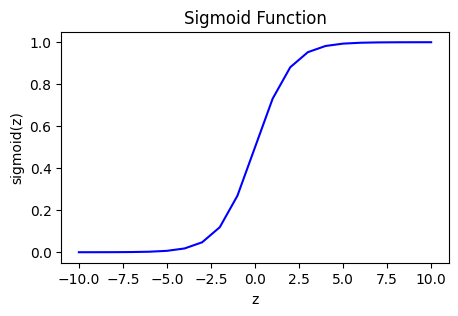

In [93]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

ax.plot(z_tmp, y, c="b")

ax.set_title("Sigmoid Function")
ax.set_ylabel("sigmoid(z)")
ax.set_xlabel("z")

plt.show()

In [94]:
X = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1])

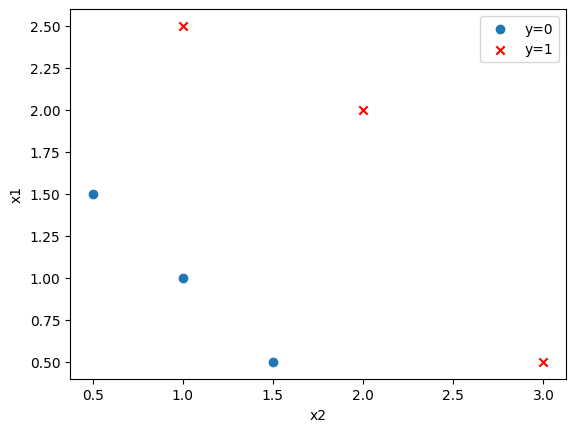

In [95]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="y=0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="x", c="r", label="y=1")

# guessed weights
w = np.array([1, 1])
b = -3


plt.ylabel("x1")
plt.xlabel("x2")

plt.legend()

plt.show()

In [96]:
def compute_z(x: np.ndarray, w, b):
    return np.dot(x, w) + b

In [97]:
def compute_cost(x: np.ndarray, y: np.ndarray, w: np.ndarray, b):
    m = x.shape[0]

    z = compute_z(x, w, b)

    pred = sigmoid_func(z)

    epsilon = 1e-15  # to prevent log(0)

    cost = np.dot(y, np.log(pred + epsilon)) + np.dot(
        (1 - y), np.log(1 - pred + epsilon)
    )

    cost /= -m

    return cost

In [98]:
n = X.shape[1]
w = np.zeros(n)
b = 0

learning_rate = 0.1
iterations = 10000

In [99]:
def compute_gradient(x: np.ndarray, y: np.ndarray, w: np.ndarray, b):
    m = x.shape[0]

    z = compute_z(x, w, b)
    y_hat = sigmoid_func(z)

    error = y_hat - y

    dj_dw = np.dot(x.T, error) / m
    dj_db = np.sum(error) / m

    return dj_dw, dj_db

In [100]:
def gradient_descent(
    x: np.ndarray, y: np.ndarray, w_in: np.ndarray, b_in, alpha, iterations
):
    w = w_in.copy()
    b = b_in

    m = x.shape[0]
    n = x.shape[1]

    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration: {i}, Cost: {cost}")

    return w, b, cost_history

In [101]:
w_final, b_final, cost_hist = gradient_descent(X, y, w, b, learning_rate, iterations)

Iteration: 0, Cost: 0.6846104685605718
Iteration: 100, Cost: 0.5290450209691845
Iteration: 200, Cost: 0.4341520395446077
Iteration: 300, Cost: 0.36410903699090974
Iteration: 400, Cost: 0.31125469244504683
Iteration: 500, Cost: 0.2704706250711678
Iteration: 600, Cost: 0.23832522010961468
Iteration: 700, Cost: 0.21249424771338407
Iteration: 800, Cost: 0.19137639252601335
Iteration: 900, Cost: 0.17384645269746257
Iteration: 1000, Cost: 0.15909776668704445
Iteration: 1100, Cost: 0.14654075982377554
Iteration: 1200, Cost: 0.1357366527440628
Iteration: 1300, Cost: 0.12635338520979764
Iteration: 1400, Cost: 0.11813577400424992
Iteration: 1500, Cost: 0.11088494273239842
Iteration: 1600, Cost: 0.10444389655046099
Iteration: 1700, Cost: 0.09868724008064635
Iteration: 1800, Cost: 0.09351373574688819
Iteration: 1900, Cost: 0.08884084055797974
Iteration: 2000, Cost: 0.08460064176929975
Iteration: 2100, Cost: 0.08073679567893452
Iteration: 2200, Cost: 0.07720219534218234
Iteration: 2300, Cost: 0.073

Text(0, 0.5, 'Cost')

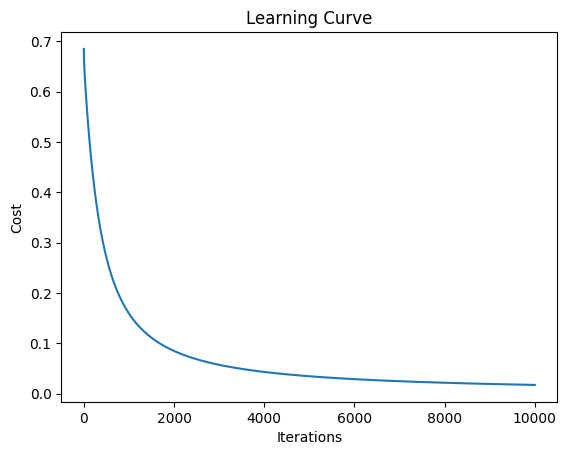

In [102]:
plt.plot(cost_hist)
plt.title("Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("Cost")

In [103]:
print(f"Final parameters:\n w = {w_final}\nb = {b_final}")

Final parameters:
 w = [5.28123029 5.07815608]
b = -14.222409982019839


In [104]:
def predict(x: np.ndarray, w: np.ndarray, b):
    z = compute_z(x, w, b)
    prob = sigmoid_func(z)

    return int((prob >= 0.5))

In [105]:
n = X.shape[1]

features = np.zeros(n)

for i in range(n):
    value = float(input(f"Enter x{i+1}: "))

    features[i] = value

prediction = predict(features, w_final, b_final)

print(f"Prediction: {prediction}")

Prediction: 1
